# Evaluation — Seasonality, Trends & Spatial Correlation — E3\_pole\_tower

**Purpose:** Assess temporal and spatial skill of the E3\_pole\_tower
model using the `combined` predictions (2001–2020).

| Part | Content |
|-----:|---------|
| 0–4 | Configuration, imports, data loading, features, re-prediction |
| A | Monthly seasonality (dual-axis, raw values) |
| B | Monthly seasonality by subregion (dual-axis) |
| C | Annual trend (dual-axis) |
| D | Monthly × subregion Spearman correlation matrix |
| E | County-level seasonal Spearman maps |
| F | Spatial maps — fire frequency & mean predictions |

## 0. Configuration

In [1]:
import os

# ======================== PATHS ========================
DATA_ROOT    = r"E:\zcao\CA_Wildfire"
DATA_VERSION = "Monthly_03152026_calibration"
DATA_DIR     = os.path.join(DATA_ROOT, "Clean_Data", "Model_Data",
                            "Evaluation", "Features_w_Label", DATA_VERSION)

PROJECT_ROOT = r"E:\zcao\Ignition - ML Modeling"

# ---------- Experiment to analyse ----------
EXP_NAME    = "E3_pole_tower"
LEN_TRAIN   = 6
TAG         = f"{EXP_NAME}__LT{LEN_TRAIN}"

MODEL_DIR   = os.path.join(PROJECT_ROOT, "Models", TAG)
PLOT_DIR    = os.path.join(PROJECT_ROOT, "Plots", TAG)

for d in [PLOT_DIR]:
    os.makedirs(d, exist_ok=True)

LABEL_COL     = "IS_FIRE"
PREDICT_YEARS = list(range(2001, 2021))

print(f"Data dir  : {DATA_DIR}")
print(f"Model dir : {MODEL_DIR}")
print(f"  [{'OK' if os.path.isdir(DATA_DIR) else 'MISSING'}] DATA_DIR")
print(f"  [{'OK' if os.path.isdir(MODEL_DIR) else 'MISSING'}] MODEL_DIR")

Data dir  : E:\zcao\CA_Wildfire\Clean_Data\Model_Data\Evaluation\Features_w_Label\Monthly_03152026_calibration
Model dir : E:\zcao\Ignition - ML Modeling\Models\E3_pole_tower__LT6
  [OK] DATA_DIR
  [OK] MODEL_DIR


## 1. Imports

In [2]:
import sys, gc, warnings, pickle, time
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
)
from scipy.stats import spearmanr, pearsonr
import xgboost as xgb

## 2. Load & Prepare Data

In [3]:
# --- Load splits --------------------------------------------------------
cali_data = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_calibration.parquet"))
mod_data = pd.read_parquet(
    os.path.join(DATA_DIR, "monthly_model_data_by_year_non_calibration.parquet"))

# --- Rename octant day-count cols ----------------------------------------
octant_dirs = ["N", "NE", "E", "SE", "S", "SW", "W", "NW"]
rename_map  = {f"wind_direction_category_{d}": f"wind_direction_category_{d}_freq"
               for d in octant_dirs}
cali_data = cali_data.rename(columns=rename_map)
mod_data  = mod_data.rename(columns=rename_map)

# --- One-hot encode categoricals ----------------------------------------
cat_cols = ["veg_group", "wind_direction_category"]
cali_data = pd.get_dummies(cali_data, columns=cat_cols)
mod_data  = pd.get_dummies(mod_data,  columns=cat_cols)

# --- Derive month column ------------------------------------------------
if "month" not in mod_data.columns:
    mod_data["month"]  = mod_data["year_month"].dt.month
    cali_data["month"] = cali_data["year_month"].dt.month

print(f"Non-calibration : {mod_data.shape}  fire rate: {mod_data[LABEL_COL].mean():.4f}")
print(f"Calibration     : {cali_data.shape}")
print(f"SubRegion present: {'SubRegion' in mod_data.columns}")

Non-calibration : (3396205, 81)  fire rate: 0.0194
Calibration     : (377356, 81)
SubRegion present: True


## 3. Define Features (E3\_pole\_tower)

In [4]:
BASE_FEATURES = [
    "dead_fuel_moisture_1000hr", "dead_fuel_moisture_100hr",
    "max_air_temperature",      "min_air_temperature",
    "max_relative_humidity",    "min_relative_humidity",
    "precipitation_amount",     "specific_humidity",
    "surface_downwelling_shortwave_flux_in_air",
    "wind_speed", "SWE",
    "wind_direction_category_N",  "wind_direction_category_NE",
    "wind_direction_category_E",  "wind_direction_category_SE",
    "wind_direction_category_S",  "wind_direction_category_SW",
    "wind_direction_category_W",  "wind_direction_category_NW",
    "veg_group_Chaparral",    "veg_group_Conifer Alpine",
    "veg_group_Conifer Forest", "veg_group_Grassland",
    "veg_group_Oak Woodland", "veg_group_Shrub",
    "LAI", "slope_max", "slope_avg",
    "road_density_km_km2",
    "prev_fire",
]

EXTRA_FEATURES = ["pole_density", "tower_density"]
features = BASE_FEATURES + EXTRA_FEATURES
print(f"Total features: {len(features)}")

Total features: 32


## 4. Re-predict All Water Years

Build the `combined` DataFrame with predictions and metadata columns
(`SubRegion`, `month`, `lat`, `lon`) needed by all downstream analyses.

In [5]:
def get_base_model(cal_model):
    """Extract the underlying XGBoost estimator from CalibratedClassifierCV."""
    return getattr(cal_model, "estimator",
                   getattr(cal_model, "base_estimator", None))

# Columns to carry through
keep_cols = ["water_year", "month", "lat", "lon", LABEL_COL]
if "SubRegion" in mod_data.columns:
    keep_cols.append("SubRegion")

yearly_preds = []

for year in tqdm(PREDICT_YEARS, desc="Re-predicting"):
    pkl_path = os.path.join(MODEL_DIR, f"predict_{year}.pkl")
    if not os.path.exists(pkl_path):
        print(f"  WY {year}: model not found — skipping")
        continue

    with open(pkl_path, "rb") as fh:
        cal_model = pickle.load(fh)

    evl = mod_data[mod_data["water_year"] == year].copy()
    if evl.empty:
        continue

    proba = cal_model.predict_proba(evl[features])[:, 1]

    out = evl[keep_cols].copy()
    out["predictions"] = proba
    yearly_preds.append(out)

    del cal_model, evl
    gc.collect()

combined    = pd.concat(yearly_preds, ignore_index=True)
water_years = sorted(combined["water_year"].unique())

print(f"Combined : {combined.shape[0]:,} rows, {len(water_years)} water years")
print(f"Fire rate: {combined[LABEL_COL].mean():.4f}")
print(f"Columns  : {list(combined.columns)}")

Re-predicting: 100%|██████████| 20/20 [00:10<00:00,  1.91it/s]

Combined : 2,542,121 rows, 20 water years
Fire rate: 0.0185
Columns  : ['water_year', 'month', 'lat', 'lon', 'IS_FIRE', 'SubRegion', 'predictions']


---
# Part A — Monthly Fire Seasonality (Dual-Axis, Raw Values)

=== Multi-Year Monthly Fire Distribution Analysis ===
Spearman rho = 0.9790, p = 0.0000


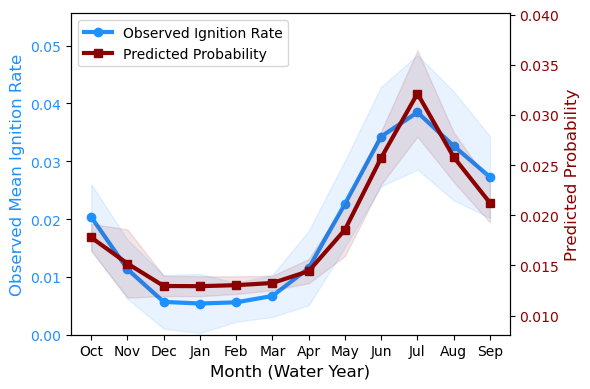


Monthly Summary:
month_name  fire_mean  pred_mean
       Oct   0.020363   0.017781
       Nov   0.011324   0.015185
       Dec   0.005678   0.012948
       Jan   0.005398   0.012930
       Feb   0.005602   0.013028
       Mar   0.006702   0.013246
       Apr   0.011516   0.014425
       May   0.022625   0.018556
       Jun   0.034271   0.025722
       Jul   0.038462   0.032130
       Aug   0.032649   0.025795
       Sep   0.027279   0.021236


In [6]:
print("=== Multi-Year Monthly Fire Distribution Analysis ===")

# === 1. Filter ===
df_eval = combined[combined['water_year'].between(2001, 2020)].copy()

# === 2. Pixel monthly averages ===
pixel_monthly = (
    df_eval.groupby(['water_year', 'month', 'lat', 'lon'])
    .agg(fire_sum=('IS_FIRE', 'mean'), pred_mean=('predictions', 'mean'))
    .reset_index()
)

# === 3. Regional average per month ===
monthly_regional = (
    pixel_monthly.groupby(['water_year', 'month'])[['fire_sum', 'pred_mean']]
    .mean().reset_index()
)

# === 4. Multi-year monthly statistics (water-year order) ===
monthly_stats = (
    monthly_regional.groupby('month')[['fire_sum', 'pred_mean']]
    .agg(['mean', 'std']).reset_index()
)
monthly_stats.columns = ['month', 'fire_mean', 'fire_std', 'pred_mean', 'pred_std']

water_year_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
monthly_stats['month_order'] = monthly_stats['month'].map(
    {m: i for i, m in enumerate(water_year_order)})
monthly_stats = monthly_stats.sort_values('month_order').reset_index(drop=True)
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar',
               'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']
monthly_stats['month_name'] = month_names

# === 5. Correlation ===
r_spearman, p_spearman = spearmanr(monthly_stats['fire_mean'],
                                    monthly_stats['pred_mean'])
print(f"Spearman rho = {r_spearman:.4f}, p = {p_spearman:.4f}")

# === 6. Dual-axis plot with aligned y-axes ===
fig, ax1 = plt.subplots(figsize=(6, 4))
x_pos = range(len(monthly_stats))

color1 = 'dodgerblue'
color2 = 'darkred'

# --- Compute aligned axis limits ---
# Use data range + 20% padding, then align both axes so curves overlap
fire_vals = monthly_stats['fire_mean']
pred_vals = monthly_stats['pred_mean']
fire_std_vals = monthly_stats['fire_std']
pred_std_vals = monthly_stats['pred_std']

# Include std bands in range calculation
fire_lo = (fire_vals - fire_std_vals).min()
fire_hi = (fire_vals + fire_std_vals).max()
pred_lo = (pred_vals - pred_std_vals).min()
pred_hi = (pred_vals + pred_std_vals).max()

# Add 15% padding
fire_pad = 0.15 * (fire_hi - fire_lo)
pred_pad = 0.15 * (pred_hi - pred_lo)

fire_ymin = max(0, fire_lo - fire_pad)
fire_ymax = fire_hi + fire_pad
pred_ymin = max(0, pred_lo - pred_pad)
pred_ymax = pred_hi + pred_pad

# Left axis — observed fire rate
ax1.plot(x_pos, fire_vals, marker='o', color=color1,
         linewidth=3, markersize=6, label='Observed Ignition Rate')
ax1.fill_between(x_pos,
                 fire_vals - fire_std_vals,
                 fire_vals + fire_std_vals,
                 color=color1, alpha=0.1)
ax1.set_xlabel('Month (Water Year)', fontsize=12)
ax1.set_ylabel('Observed Mean Ignition Rate', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names)
ax1.set_ylim(fire_ymin, fire_ymax)

# Right axis — predicted probability
ax2 = ax1.twinx()
ax2.plot(x_pos, pred_vals, marker='s', color=color2,
         linewidth=3, markersize=6, label='Predicted Probability')
ax2.fill_between(x_pos,
                 pred_vals - pred_std_vals,
                 pred_vals + pred_std_vals,
                 color=color2, alpha=0.1)
ax2.set_ylabel('Predicted Probability', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(pred_ymin, pred_ymax)

# Correlation annotation
#ax1.text(0.02, 0.96, f'Spearman \u03c1 = {r_spearman:.4f} (p = {p_spearman:.4f})',
#         transform=ax1.transAxes, fontsize=11, fontweight='bold',
#         verticalalignment='top',
#         bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9))

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.grid(False)
ax2.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Monthly_Seasonality_DualAxis.png"),
            dpi=300, bbox_inches="tight")
plt.show()

print("\nMonthly Summary:")
print(monthly_stats[['month_name', 'fire_mean', 'pred_mean']].round(6).to_string(index=False))

---
# Part B — Monthly Fire Seasonality by Subregion (Dual-Axis)

=== Multi-Year Monthly Fire Distribution by Subregion ===
Found 5 subregions: ['Central Coast', 'North Coast', 'North Interior', 'Sierra Nevada', 'South Coast']
  Central Coast: rho = 0.9930 (p = 0.0000)
  North Coast: rho = 0.9930 (p = 0.0000)
  North Interior: rho = 0.9650 (p = 0.0000)
  Sierra Nevada: rho = 0.9720 (p = 0.0000)
  South Coast: rho = 0.9720 (p = 0.0000)


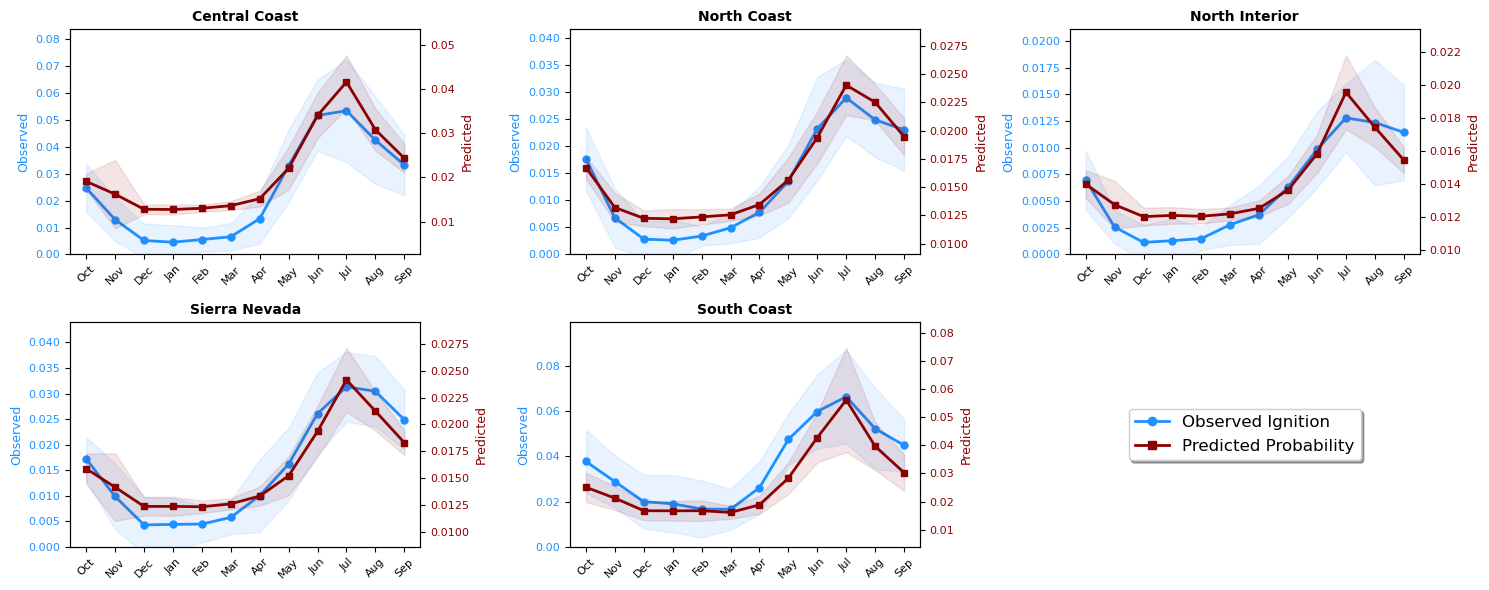

In [7]:
print("=== Multi-Year Monthly Fire Distribution by Subregion ===")

df_eval = combined[combined['water_year'].between(2001, 2020)].copy()

pixel_monthly = (
    df_eval.groupby(['water_year', 'month', 'SubRegion', 'lat', 'lon'])
    .agg(fire_sum=('IS_FIRE', 'sum'), pred_mean=('predictions', 'mean'))
    .reset_index()
)

monthly_subregional = (
    pixel_monthly.groupby(['water_year', 'month', 'SubRegion'])[['fire_sum', 'pred_mean']]
    .mean().reset_index()
)

subregions = sorted(monthly_subregional['SubRegion'].unique())
print(f"Found {len(subregions)} subregions: {subregions}")

water_year_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
month_names = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar',
               'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep']

subregion_results = {}

for subregion in subregions:
    sub_data = monthly_subregional[monthly_subregional['SubRegion'] == subregion]
    stats = (
        sub_data.groupby('month')[['fire_sum', 'pred_mean']]
        .agg(['mean', 'std']).reset_index()
    )
    stats.columns = ['month', 'fire_mean', 'fire_std', 'pred_mean', 'pred_std']
    stats['month_order'] = stats['month'].map(
        {m: i for i, m in enumerate(water_year_order)})
    stats = stats.sort_values('month_order').reset_index(drop=True)
    stats['month_name'] = month_names

    r_sp, p_sp = spearmanr(stats['fire_mean'], stats['pred_mean'])
    subregion_results[subregion] = {'data': stats, 'r': r_sp, 'p': p_sp}
    print(f"  {subregion}: rho = {r_sp:.4f} (p = {p_sp:.4f})")

# --- Plot: 2 rows x 3 cols, aligned dual-axis per panel -----------------
n_sub = len(subregions)
n_cols = 3
n_rows = (n_sub + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

color1 = 'dodgerblue'
color2 = 'darkred'

for idx, subregion in enumerate(subregions):
    row, col = idx // n_cols, idx % n_cols
    ax1 = axes[row, col]

    data = subregion_results[subregion]['data']
    r_sp = subregion_results[subregion]['r']
    p_sp = subregion_results[subregion]['p']
    x_pos = range(len(data))

    # Compute aligned axis limits with padding
    f_lo = (data['fire_mean'] - data['fire_std']).min()
    f_hi = (data['fire_mean'] + data['fire_std']).max()
    p_lo = (data['pred_mean'] - data['pred_std']).min()
    p_hi = (data['pred_mean'] + data['pred_std']).max()
    f_pad = 0.15 * (f_hi - f_lo) if f_hi > f_lo else 0.001
    p_pad = 0.15 * (p_hi - p_lo) if p_hi > p_lo else 0.001

    # Left axis — observed
    ax1.plot(x_pos, data['fire_mean'], marker='o', color=color1,
             linewidth=2, markersize=5)
    ax1.fill_between(x_pos,
                     data['fire_mean'] - data['fire_std'],
                     data['fire_mean'] + data['fire_std'],
                     color=color1, alpha=0.1)
    ax1.set_ylabel('Observed', fontsize=9, color=color1)
    ax1.tick_params(axis='y', labelcolor=color1, labelsize=8)
    ax1.set_ylim(max(0, f_lo - f_pad), f_hi + f_pad)

    # Right axis — predicted
    ax2 = ax1.twinx()
    ax2.plot(x_pos, data['pred_mean'], marker='s', color=color2,
             linewidth=2, markersize=5)
    ax2.fill_between(x_pos,
                     data['pred_mean'] - data['pred_std'],
                     data['pred_mean'] + data['pred_std'],
                     color=color2, alpha=0.1)
    ax2.set_ylabel('Predicted', fontsize=9, color=color2)
    ax2.tick_params(axis='y', labelcolor=color2, labelsize=8)
    ax2.set_ylim(max(0, p_lo - p_pad), p_hi + p_pad)

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(data['month_name'], rotation=45, fontsize=8)
    #ax1.set_title(f'{subregion}\n\u03c1 = {r_sp:.3f} (p = {p_sp:.3f})',
    #              fontsize=10, fontweight='bold')
    ax1.set_title(f'{subregion}', fontsize=10, fontweight='bold')
    ax1.grid(False)
    ax2.grid(False)

# Legend in last panel
for idx in range(n_sub, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row, col]
    if idx == n_sub:
        ax.axis('off')
        l1 = ax.plot([], [], marker='o', color=color1,
                     label='Observed Ignition', linewidth=2, markersize=6)[0]
        l2 = ax.plot([], [], marker='s', color=color2,
                     label='Predicted Probability', linewidth=2, markersize=6)[0]
        ax.legend(handles=[l1, l2], loc='center', fontsize=12,
                  frameon=True, fancybox=True, shadow=True)
    else:
        ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Monthly_Seasonality_Subregion_DualAxis.png"),
            dpi=300, bbox_inches="tight")
plt.show()

---
# Part C — Annual Trend (Dual-Axis, Raw Values)

=== Annual Fire Prediction Trend Analysis ===
Spearman rho = 0.785, p = 0.0000


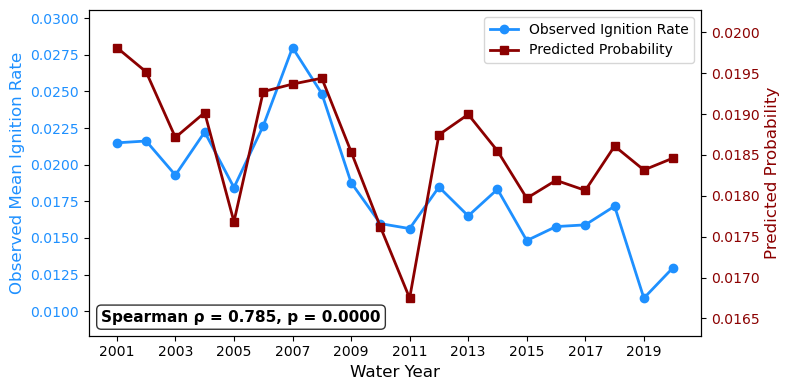


Annual Summary:
 water_year  fire_sum  pred_mean
       2001  0.021490   0.019814
       2002  0.021615   0.019516
       2003  0.019289   0.018714
       2004  0.022226   0.019018
       2005  0.018440   0.017683
       2006  0.022647   0.019275
       2007  0.027989   0.019367
       2008  0.024852   0.019439
       2009  0.018780   0.018540
       2010  0.015978   0.017620
       2011  0.015640   0.016747
       2012  0.018474   0.018747
       2013  0.016505   0.018996
       2014  0.018323   0.018549
       2015  0.014821   0.017970
       2016  0.015776   0.018189
       2017  0.015894   0.018066
       2018  0.017168   0.018608
       2019  0.010894   0.018316
       2020  0.012981   0.018462


In [8]:
print("=== Annual Fire Prediction Trend Analysis ===")

df_eval = combined[combined['water_year'].between(2001, 2020)].copy()

pixel_monthly = (
    df_eval.groupby(['water_year', 'month', 'lat', 'lon'])
    .agg(fire_sum=('IS_FIRE', 'sum'), pred_mean=('predictions', 'mean'))
    .reset_index()
)

monthly_regional = (
    pixel_monthly.groupby(['water_year', 'month'])[['fire_sum', 'pred_mean']]
    .mean().reset_index()
)

annual_avg = (
    monthly_regional.groupby('water_year')[['fire_sum', 'pred_mean']]
    .mean().reset_index()
)

r_annual, p_annual = spearmanr(annual_avg['fire_sum'], annual_avg['pred_mean'])
print(f"Spearman rho = {r_annual:.3f}, p = {p_annual:.4f}")

# --- Aligned dual-axis plot ----------------------------------------------
fig, ax1 = plt.subplots(figsize=(8, 4))

color1 = 'dodgerblue'
color2 = 'darkred'

fire_vals = annual_avg['fire_sum']
pred_vals = annual_avg['pred_mean']

# Aligned limits with 15% padding
f_lo, f_hi = fire_vals.min(), fire_vals.max()
p_lo, p_hi = pred_vals.min(), pred_vals.max()
f_pad = 0.15 * (f_hi - f_lo)
p_pad = 0.15 * (p_hi - p_lo)

ax1.plot(annual_avg['water_year'], fire_vals,
         marker='o', color=color1, linewidth=2, markersize=6,
         label='Observed Ignition Rate')
ax1.set_xlabel('Water Year', fontsize=12)
ax1.set_ylabel('Observed Mean Ignition Rate', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(np.arange(2001, 2021, 2))
ax1.set_ylim(max(0, f_lo - f_pad), f_hi + f_pad)

ax2 = ax1.twinx()
ax2.plot(annual_avg['water_year'], pred_vals,
         marker='s', color=color2, linewidth=2, markersize=6,
         label='Predicted Probability')
ax2.set_ylabel('Predicted Probability', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(max(0, p_lo - p_pad), p_hi + p_pad)

ax1.text(0.02, 0.08, f'Spearman \u03c1 = {r_annual:.3f}, p = {p_annual:.4f}',
         transform=ax1.transAxes, fontsize=11, fontweight='bold',
         verticalalignment='top',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.grid(False)
ax2.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Annual_Trend_DualAxis.png"),
            dpi=300, bbox_inches="tight")
plt.show()

print("\nAnnual Summary:")
print(annual_avg[['water_year', 'fire_sum', 'pred_mean']].round(6).to_string(index=False))

---
# Part D — Monthly × Subregion Spearman Correlation Matrix

In [9]:
print("=== Monthly-Subregional Fire Prediction Correlation Analysis ===")

month_names_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
                   7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

df_eval = combined[combined['water_year'].between(2001, 2020)].copy()

# Pixel monthly by subregion
pixel_monthly = (
    df_eval.groupby(['water_year', 'month', 'SubRegion', 'lat', 'lon'])
    .agg(fire_sum=('IS_FIRE', 'sum'), pred_mean=('predictions', 'mean'))
    .reset_index()
)

# Monthly totals by subregion and year
monthly_subregional = (
    pixel_monthly.groupby(['water_year', 'month', 'SubRegion'])
    .agg(fire_sum=('fire_sum', 'sum'), pred_mean=('pred_mean', 'mean'))
    .reset_index()
)

subregions = sorted(monthly_subregional['SubRegion'].unique())
months     = sorted(monthly_subregional['month'].unique())
years      = sorted(monthly_subregional['water_year'].unique())

print(f"Subregions: {subregions}")
print(f"Years: {min(years)}–{max(years)} ({len(years)} years)")

# --- Compute correlations per subregion × month --------------------------
water_year_months = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
available_months  = [m for m in water_year_months if m in months]
month_labels      = [month_names_map[m] for m in available_months]

correlation_matrix = []
p_value_matrix     = []

for subregion in subregions:
    corr_row, p_row = [], []
    for month in available_months:
        combo = monthly_subregional[
            (monthly_subregional['SubRegion'] == subregion) &
            (monthly_subregional['month'] == month)]

        fire_std = combo['fire_sum'].std()
        pred_std = combo['pred_mean'].std()

        if len(combo) < 5 or fire_std == 0 or pred_std == 0:
            corr_row.append(np.nan)
            p_row.append(np.nan)
        else:
            r, p = spearmanr(combo['fire_sum'], combo['pred_mean'])
            corr_row.append(r)
            p_row.append(p)

    correlation_matrix.append(corr_row)
    p_value_matrix.append(p_row)

corr_df = pd.DataFrame(correlation_matrix, index=subregions, columns=month_labels)
pval_df = pd.DataFrame(p_value_matrix,     index=subregions, columns=month_labels)

# --- Build annotated table with significance stars -----------------------
def sig_stars(p):
    if pd.isna(p):
        return ''
    if p < 0.01:
        return '***'
    if p < 0.05:
        return '**'
    if p < 0.1:
        return '*'
    return ''

annotated_df = corr_df.copy()
for col in annotated_df.columns:
    for row in annotated_df.index:
        r_val = corr_df.loc[row, col]
        p_val = pval_df.loc[row, col]
        if pd.isna(r_val):
            annotated_df.loc[row, col] = '—'
        else:
            annotated_df.loc[row, col] = f"{r_val:.3f}{sig_stars(p_val)}"

print("\nSpearman ρ with significance stars:")
print("(* p < 0.1, ** p < 0.05, *** p < 0.01)")
print(annotated_df.to_string())

# --- Summary stats -------------------------------------------------------
valid   = corr_df.values[~np.isnan(corr_df.values)]
valid_p = pval_df.values[~np.isnan(pval_df.values)]

n_sig_01 = (valid_p < 0.01).sum()
n_sig_05 = (valid_p < 0.05).sum()
n_sig_10 = (valid_p < 0.1).sum()

print(f"\nOverall: mean ρ = {valid.mean():.3f}")
print(f"  p < 0.01 (***): {n_sig_01}/{len(valid_p)}")
print(f"  p < 0.05 (**)  : {n_sig_05}/{len(valid_p)}")
print(f"  p < 0.1  (*)   : {n_sig_10}/{len(valid_p)}")

# Monthly summary
print(f"\n{'Month':<6} {'N':<4} {'Mean ρ':<8} {'% ***':<8} {'% **':<8} {'% *':<8}")
for i, ml in enumerate(month_labels):
    mc = corr_df.iloc[:, i].dropna()
    mp = pval_df.iloc[:, i].dropna()
    if len(mc) > 0:
        print(f"{ml:<6} {len(mc):<4} {mc.mean():<8.3f} "
              f"{100 * (mp < 0.01).sum() / len(mp):<8.1f} "
              f"{100 * (mp < 0.05).sum() / len(mp):<8.1f} "
              f"{100 * (mp < 0.1).sum() / len(mp):<8.1f}")

# Subregional summary
print(f"\n{'Subregion':<15} {'N':<4} {'Mean ρ':<8} {'% ***':<8} {'% **':<8} {'% *':<8}")
for i, sr in enumerate(subregions):
    sc = corr_df.iloc[i, :].dropna()
    sp = pval_df.iloc[i, :].dropna()
    if len(sc) > 0:
        print(f"{sr:<15} {len(sc):<4} {sc.mean():<8.3f} "
              f"{100 * (sp < 0.01).sum() / len(sp):<8.1f} "
              f"{100 * (sp < 0.05).sum() / len(sp):<8.1f} "
              f"{100 * (sp < 0.1).sum() / len(sp):<8.1f}")

=== Monthly-Subregional Fire Prediction Correlation Analysis ===
Subregions: ['Central Coast', 'North Coast', 'North Interior', 'Sierra Nevada', 'South Coast']
Years: 2001–2020 (20 years)

Spearman ρ with significance stars:
(* p < 0.1, ** p < 0.05, *** p < 0.01)
                    Oct      Nov       Dec       Jan       Feb       Mar       Apr       May      Jun       Jul       Aug       Sep
Central Coast     0.077    0.334   0.530**  0.604***   0.556**  0.596***  0.657***  0.727***    0.357  0.667***  0.900***    0.430*
North Coast     0.451**    0.246     0.310   0.512**    0.419*    0.442*   0.551**  0.649***  0.445**     0.343    0.385*     0.362
North Interior    0.154    0.220     0.149   0.471**     0.021    0.407*   0.510**    0.419*    0.084    -0.118    -0.152     0.277
Sierra Nevada    -0.023   0.399*     0.331  0.581***   0.541**  0.670***  0.719***  0.712***  0.449**    0.442*     0.346     0.133
South Coast      0.436*  0.504**  0.660***  0.594***  0.595***  0.796***  0.

---
# Part E — County-Level Seasonal Spearman Maps

In [10]:
import geopandas as gpd
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# === 1. Spatial join ===
print("Spatial join to counties...")
df_eval = combined[combined['water_year'].between(2001, 2020)].copy()

gdf_pixels = gpd.GeoDataFrame(
    df_eval,
    geometry=gpd.points_from_xy(df_eval['lon'], df_eval['lat']),
    crs='EPSG:4326'
)

counties = gpd.read_file(
    "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json"
)
counties = counties[counties['STATE'] == '06'].to_crs('EPSG:4326')

gdf_joined = gpd.sjoin(gdf_pixels, counties[['NAME', 'geometry']],
                        how='left', predicate='within')
gdf_joined = gdf_joined.rename(columns={'NAME': 'county'})
gdf_joined = gdf_joined.dropna(subset=['county'])

print(f"Pixels matched: {len(gdf_joined)} / {len(df_eval)}")
print(f"Counties found: {gdf_joined['county'].nunique()}")

# === 2. Coverage check ===
print("Coverage check...")
lons = np.sort(df_eval['lon'].unique())
lats = np.sort(df_eval['lat'].unique())
lon_res = np.median(np.diff(lons))
lat_res = np.median(np.diff(lats))

lon_full = np.arange(lons.min(), lons.max() + lon_res / 2, lon_res)
lat_full = np.arange(lats.min(), lats.max() + lat_res / 2, lat_res)
lon_grid, lat_grid = np.meshgrid(lon_full, lat_full)

gdf_ref = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(lon_grid.ravel(), lat_grid.ravel()),
    crs='EPSG:4326'
)
ref_joined = gpd.sjoin(gdf_ref, counties[['NAME', 'geometry']],
                        how='left', predicate='within')
ref_joined = ref_joined.rename(columns={'NAME': 'county'})

expected_counts = ref_joined.dropna(subset=['county']).groupby('county').size().reset_index(name='expected_pixels')
actual_counts   = gdf_joined.drop_duplicates(subset=['lat', 'lon']).groupby('county').size().reset_index(name='actual_pixels')
coverage_df = expected_counts.merge(actual_counts, on='county', how='left')
coverage_df['actual_pixels'] = coverage_df['actual_pixels'].fillna(0)
coverage_df['coverage_ratio'] = coverage_df['actual_pixels'] / coverage_df['expected_pixels']
low_coverage_counties = coverage_df[coverage_df['coverage_ratio'] < 0.1]['county'].tolist()
print(f"Low-coverage counties excluded: {len(low_coverage_counties)}")

Spatial join to counties...
Pixels matched: 2541901 / 2542121
Counties found: 55
Coverage check...
Low-coverage counties excluded: 3



Wet Season (Oct–Apr):
  Valid: 34  |  Significant: 9
  Mean ρ: 0.316

Early Fire Season (May–Jun):
  Valid: 33  |  Significant: 19
  Mean ρ: 0.401

Peak Fire Season (Jul–Sep):
  Valid: 30  |  Significant: 20
  Mean ρ: 0.404


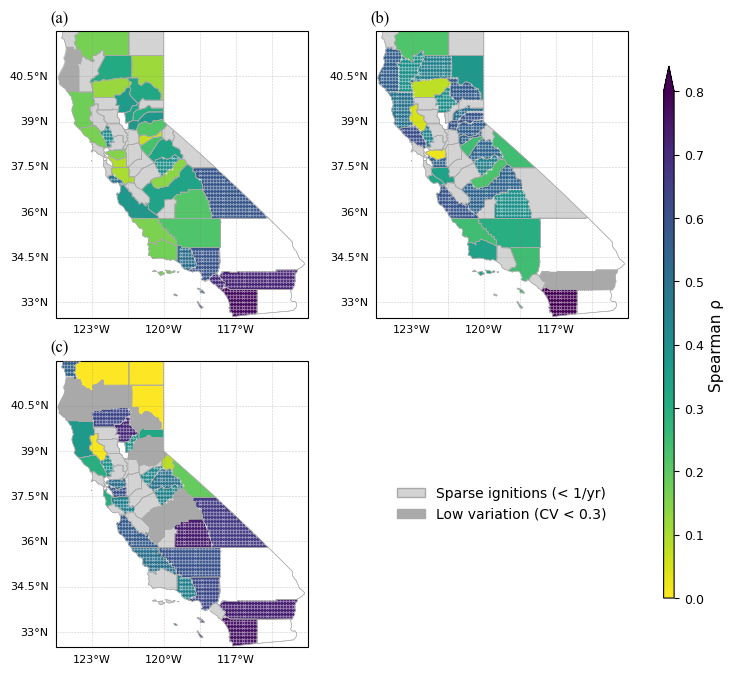

In [14]:
# === 3. Seasonal county maps (2×2 panel, legend in 4th subplot) ===
CV_THRESHOLD = 0.3

seasons = {
    'Wet Season\n(Oct–Apr)':        [10, 11, 12, 1, 2, 3, 4],
    'Early Fire Season\n(May–Jun)': [5, 6],
    'Peak Fire Season\n(Jul–Sep)':  [7, 8, 9],
}

cmap_map = plt.cm.viridis_r
norm_map = plt.Normalize(vmin=0, vmax=0.8)

fig = plt.figure(figsize=(7, 7))

map_positions = [221, 222, 223]
axes = [fig.add_subplot(pos, projection=ccrs.PlateCarree()) for pos in map_positions]
ax_legend = fig.add_subplot(224)
ax_legend.axis('off')

panel_labels = ['(a)', '(b)', '(c)']
tnr = {'fontname': 'Times New Roman', 'fontsize': 12}

for ax, (season_label, season_months), panel_label in zip(axes, seasons.items(), panel_labels):
    season_gdf = gdf_joined[gdf_joined['month'].isin(season_months)].copy()

    county_annual = (
        season_gdf.groupby(['county', 'water_year'])
        .agg(fire_sum=('IS_FIRE', 'sum'), pred_mean=('predictions', 'mean'))
        .reset_index()
    )

    results, excluded = [], []
    for county, grp in county_annual.groupby('county'):
        if county in low_coverage_counties:
            excluded.append({'county': county, 'reason': 'low_coverage'})
            continue
        grp = grp.sort_values('water_year')
        if len(grp) < 5:
            excluded.append({'county': county, 'reason': 'insufficient_years'})
            continue
        if (grp['fire_sum'] < 1).any():
            excluded.append({'county': county, 'reason': 'low_fire_count'})
            continue

        fire_mean, fire_std = grp['fire_sum'].mean(), grp['fire_sum'].std()
        pred_std = grp['pred_mean'].std()
        if fire_std == 0 or pred_std == 0:
            excluded.append({'county': county, 'reason': 'low_variation'})
            continue
        cv = fire_std / fire_mean
        if cv < CV_THRESHOLD:
            excluded.append({'county': county, 'reason': 'low_variation'})
            continue

        r, p = spearmanr(grp['fire_sum'], grp['pred_mean'])
        results.append({
            'county': county, 'spearman_r': r, 'p_value': p,
            'n_years': len(grp), 'cv': cv,
            'significant': (p < 0.1) and (r >= 0)
        })

    corr_df_county = pd.DataFrame(results)
    excluded_df    = pd.DataFrame(excluded) if excluded else pd.DataFrame(columns=['county', 'reason'])

    low_fire_counties_s = excluded_df[excluded_df['reason'] == 'low_fire_count']['county'].tolist()
    low_var_counties_s  = excluded_df[excluded_df['reason'] == 'low_variation']['county'].tolist()

    print(f"\n{season_label.replace(chr(10), ' ')}:")
    print(f"  Valid: {len(corr_df_county)}  |  "
          f"Significant: {corr_df_county['significant'].sum() if len(corr_df_county) else 0}")
    if len(corr_df_county):
        print(f"  Mean ρ: {corr_df_county['spearman_r'].mean():.3f}")

    # Category assignment
    counties_plot = counties.merge(corr_df_county, left_on='NAME', right_on='county', how='left')
    counties_plot['significant'] = counties_plot['significant'].astype('boolean')
    counties_plot['category'] = 'no_data'
    counties_plot.loc[counties_plot['NAME'].isin(low_fire_counties_s), 'category'] = 'low_fire'
    counties_plot.loc[counties_plot['NAME'].isin(low_var_counties_s),  'category'] = 'low_variation'
    # Both significant and insignificant now get colorbar coloring
    counties_plot.loc[counties_plot['spearman_r'].notna(), 'category'] = 'has_corr'

    # Draw excluded categories
    ax.set_extent([-124.5, -114.0, 32.5, 42.0], crs=ccrs.PlateCarree())
    for cat, clr in [('no_data', 'white'), ('low_fire', 'lightgray'),
                     ('low_variation', 'darkgray')]:
        counties_plot[counties_plot['category'] == cat].plot(
            ax=ax, color=clr, edgecolor='#aaaaaa', linewidth=0.4,
            transform=ccrs.PlateCarree())

    # Draw ALL valid counties (significant + insignificant) using colorbar
    has_corr = counties_plot[counties_plot['category'] == 'has_corr'].copy()
    if len(has_corr):
        colors = cmap_map(norm_map(has_corr['spearman_r'].values.astype(float)))
        has_corr.plot(ax=ax, color=colors, edgecolor='#aaaaaa', linewidth=0.4,
                      transform=ccrs.PlateCarree())

    # County borders on top
    counties_plot.plot(ax=ax, color='none', edgecolor='#aaaaaa', linewidth=0.4,
                       transform=ccrs.PlateCarree())

    # Stipple significant counties with dense white dots
    sig_counties = counties_plot[
        counties_plot['spearman_r'].notna() &
        counties_plot['significant'].fillna(False)
    ].copy()
    if len(sig_counties):
        for _, row in sig_counties.iterrows():
            geom = row.geometry
            minx, miny, maxx, maxy = geom.bounds
            # Generate grid of candidate points
            xs = np.arange(minx, maxx, 0.12)
            ys = np.arange(miny, maxy, 0.12)
            xg, yg = np.meshgrid(xs, ys)
            pts = gpd.points_from_xy(xg.ravel(), yg.ravel())
            # Keep only points inside the county polygon
            inside = [p for p in pts if geom.contains(p)]
            if inside:
                ax.scatter([p.x for p in inside], [p.y for p in inside],
                           s=0.1, color='white', zorder=10,
                           transform=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    ax.text(-0.02, 1.02, panel_label, transform=ax.transAxes,
            va='bottom', ha='left', **tnr)

# === Legend in 4th subplot ===
legend_elements = [
    mpatches.Patch(facecolor='lightgray', edgecolor='#aaaaaa', label='Sparse ignitions (< 1/yr)'),
    mpatches.Patch(facecolor='darkgray',  edgecolor='#aaaaaa', label='Low variation (CV < 0.3)'),
    #plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white',
    #           markeredgecolor='black', markersize=6, label='Significant (p < 0.1)',
    #           linestyle='None'),
]
ax_legend.legend(handles=legend_elements, loc='center',
                 fontsize=10, frameon=False)

# === Colorbar ===
cbar_ax = fig.add_axes([0.93, 0.12, 0.015, 0.76])
sm = plt.cm.ScalarMappable(cmap=cmap_map, norm=norm_map)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, extend='max')
cbar.set_label("Spearman ρ", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.subplots_adjust(top=0.93, bottom=0.05, left=0.03, right=0.91, hspace=0.15, wspace=0.08)
plt.savefig(os.path.join(PLOT_DIR, "County_Seasonal_Spearman_Maps.png"),
            dpi=300, bbox_inches="tight")
plt.show()

---
# Part F — Spatial Maps (Fire Frequency & Mean Predictions)

In [21]:
import cartopy.feature as cfeature

df_map = combined[combined['water_year'].between(2001, 2020)].copy()

Creating fire frequency map...


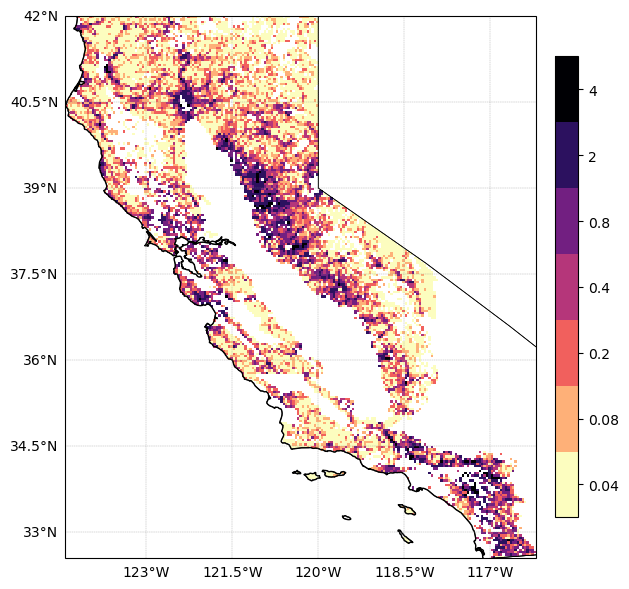

In [22]:
# === Fire Frequency Map ===
print("Creating fire frequency map...")

annual_fire = (
    df_map.groupby(['water_year', 'lat', 'lon'])['IS_FIRE']
    .sum().reset_index()
)
mean_fire = (
    annual_fire.groupby(['lat', 'lon'])['IS_FIRE']
    .mean().reset_index().rename(columns={'IS_FIRE': 'mean_fire_count'})
)

freq_2d = mean_fire.pivot(index='lat', columns='lon', values='mean_fire_count')
lats = freq_2d.index.values
lons = freq_2d.columns.values
fire_array = freq_2d.values

bounds = [0, 0.04, 0.08, 0.2, 0.4, 0.8, 2, 4]
cmap_fire = plt.get_cmap('magma_r', len(bounds) - 1)
norm_fire = BoundaryNorm(bounds, cmap_fire.N)
tick_locs = [(a + b) / 2 for a, b in zip(bounds[:-1], bounds[1:])]

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(lons, lats, fire_array, cmap=cmap_fire, norm=norm_fire, shading='auto')

ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.5)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, shrink=0.85,
                    ticks=tick_locs, spacing='uniform')
cbar.ax.set_yticklabels([f"{b}" for b in bounds[1:]])

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Spatial_Fire_Frequency.png"),
            dpi=300, bbox_inches="tight")
plt.show()

Creating mean prediction map...


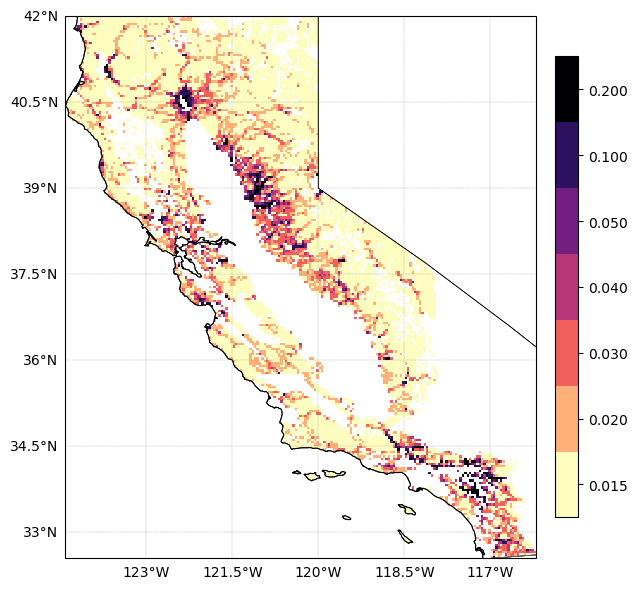

In [23]:
# === Mean Prediction Map ===
print("Creating mean prediction map...")

grouped = df_map.groupby(['water_year', 'lat', 'lon'])['predictions']
annual_mean = grouped.mean().reset_index()
mean_predictions = (
    annual_mean.groupby(['lat', 'lon'])['predictions']
    .mean().reset_index().rename(columns={'predictions': 'mean_predictions'})
)

grid_2d = mean_predictions.pivot(index='lat', columns='lon', values='mean_predictions')
lats = grid_2d.index.values
lons = grid_2d.columns.values
risk = grid_2d.values

bounds = [0, 0.015, 0.02, 0.03, 0.04, 0.05, 0.1, 0.2]
cmap_pred = plt.get_cmap('magma_r', len(bounds) - 1)
norm_pred = BoundaryNorm(bounds, ncolors=cmap_pred.N)
tick_locs = [(a + b) / 2 for a, b in zip(bounds[:-1], bounds[1:])]

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
pcm = ax.pcolormesh(lons, lats, risk, cmap=cmap_pred, norm=norm_pred, shading='auto')

ax.coastlines(resolution='10m', linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray')

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.7, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical', pad=0.02, shrink=0.85,
                    ticks=tick_locs, spacing='uniform')
cbar.ax.set_yticklabels([f"{b:.3f}" for b in bounds[1:]])

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "Spatial_Mean_Predictions.png"),
            dpi=300, bbox_inches="tight")
plt.show()

---
## Summary

In [24]:
print(f"All plots saved to: {PLOT_DIR}")
print("\nGenerated files:")
for f in sorted(os.listdir(PLOT_DIR)):
    fpath = os.path.join(PLOT_DIR, f)
    if os.path.isfile(fpath):
        print(f"  {f}")

All plots saved to: E:\zcao\Ignition - ML Modeling\Plots\E3_pole_tower__LT6

Generated files:
  AUC_PRG_TimeSeries.png
  AUC_ROC_TimeSeries.png
  Annual_Trend_DualAxis.png
  County_Seasonal_Spearman_Maps.png
  Feature_Importance_Top25.png
  Monthly_Seasonality_DualAxis.png
  Monthly_Seasonality_Subregion_DualAxis.png
  PRG_Curve_20yr.png
  ROC_Curve_20yr.png
  SHAP_Bar_Top25.png
  SHAP_Heatmap_Top10.png
  Spatial_Fire_Frequency.png
  Spatial_Mean_Predictions.png
